In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))
print(sys.path)

from BPMN.optimization import *
torch.set_default_dtype(torch.float64)
from libSOGAtruncate import truncate
import time

import torch
from torch.distributions import Normal, Categorical
import math

import BPMN.data_generating_process as dgp
import BPMN.helper_plots as hp
import matplotlib.pyplot as plt
import numpy as np


['/home/rdoz/miniconda3/envs/myenv/lib/python313.zip', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/lib-dynload', '', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages', '/home/rdoz/PhD/DeGAS/src']


/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
soga_code = """
/*  
Activities:
0) Decide shipment method
1) Pack items 
2) Request quotes from carriers
3) Select carrier
4) Check extra insurance
5) Fill in post label
6) Take extra insurance
7) Pick area
*/

array[8] tacts;    
array[8] startacts;   
array[8] endacts;  

/* Total time */
t = 0;

/* Get the activities durations */
tacts[0] = _mu0 * _mu0 + gm([1], [0.], [5.]);
tacts[1] = _mu1 * _mu1 + gm([1], [0.], [20.]);
tacts[2] = _mu2 * _mu2 + gm([1], [0.], [30.]);
tacts[3] = _mu3 * _mu3 + gm([1], [0.], [10.]);
tacts[4] = _mu4 * _mu4 + gm([1], [0.], [5.]);
tacts[5] = _mu5 * _mu5 + gm([1], [0.], [10.]);
tacts[6] = _mu6 * _mu6 + gm([1], [0.], [20.]);
tacts[7] = _mu7 * _mu7 + gm([1], [0.], [20.]);

observe(tacts[0] > 0.);
observe(tacts[1] > 0.);
observe(tacts[2] > 0.);
observe(tacts[3] > 0.);
observe(tacts[4] > 0.);
observe(tacts[5] > 0.);
observe(tacts[6] > 0.);
observe(tacts[7] > 0.);

/* Parameters of the process */
normalprob = _norm * _norm; 
extraprob = _extra * _extra;
normalprob = normalprob + gm([1], [0.], [0.1    ]);
extraprob = extraprob + gm([1], [0.], [0.1]);

/* Parallel block */
startacts[0] = t;
startacts[1] = t;

/* Branch 0 */
endacts[0] = startacts[0] + tacts[0];
branch0 = endacts[0];

if uniform([0., 1.], 2) - normalprob < 0. {
    startacts[4] = branch0;
    endacts[4] = startacts[4] + tacts[4];
    branch0 = endacts[4];

    if uniform([0., 1.], 2) - extraprob < 0. {
        startacts[6] = branch0;
        endacts[6] = startacts[6] + tacts[6];
    } else {
        skip;
    } end if;

    startacts[5] = branch0;
    endacts[5] = startacts[5] + tacts[5];

    /* branch0 = max(endacts[5], endacts[6]); */
    if endacts[5] - endacts[6] < 0. {
        branch0 = endacts[6];
    } else {
        branch0 = endacts[5];
    } end if;
} else {
    for i in range(10){
    }
    startacts[2] = branch0;
    endacts[2] = startacts[2] + tacts[2];
    startacts[3] = endacts[2];
    endacts[3] = startacts[3] + tacts[3];
    branch0 = endacts[3];
} end if;

/* Branch 1 */
endacts[1] = startacts[1] + tacts[1];
branch1 = endacts[1];

/* t = max(branch0, branch1); */
if branch0 - branch1 < 0. {
    t = branch1;
} else {
    t = branch0;
} end if;

startacts[7] = t;
endacts[7] = startacts[7] + tacts[7];

t = endacts[7];

"""

In [4]:
params = {'mu0':  60.,
          'mu1':  900., 
          'mu2':  1300.,
          'mu3':  500., 
          'mu4':  60., 
          'mu5':  500., 
          'mu6':  900.,
          'mu7':  900.,
          'norm': 0.8
          ,'extra': 0.2}

#square root all parameters to ensure positivity
for key in params:
    params[key] = params[key]**0.5
    
params_dict = initialize_params(params) 
compiledFile = compile2SOGA_text(soga_code)
cfg = produce_cfg_text(compiledFile)
smooth_cfg(cfg)
#measure execution time

start_time = time.time()

output_dist = start_SOGA(cfg, params_dict) 

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")


Execution time: 0.7370860576629639 seconds


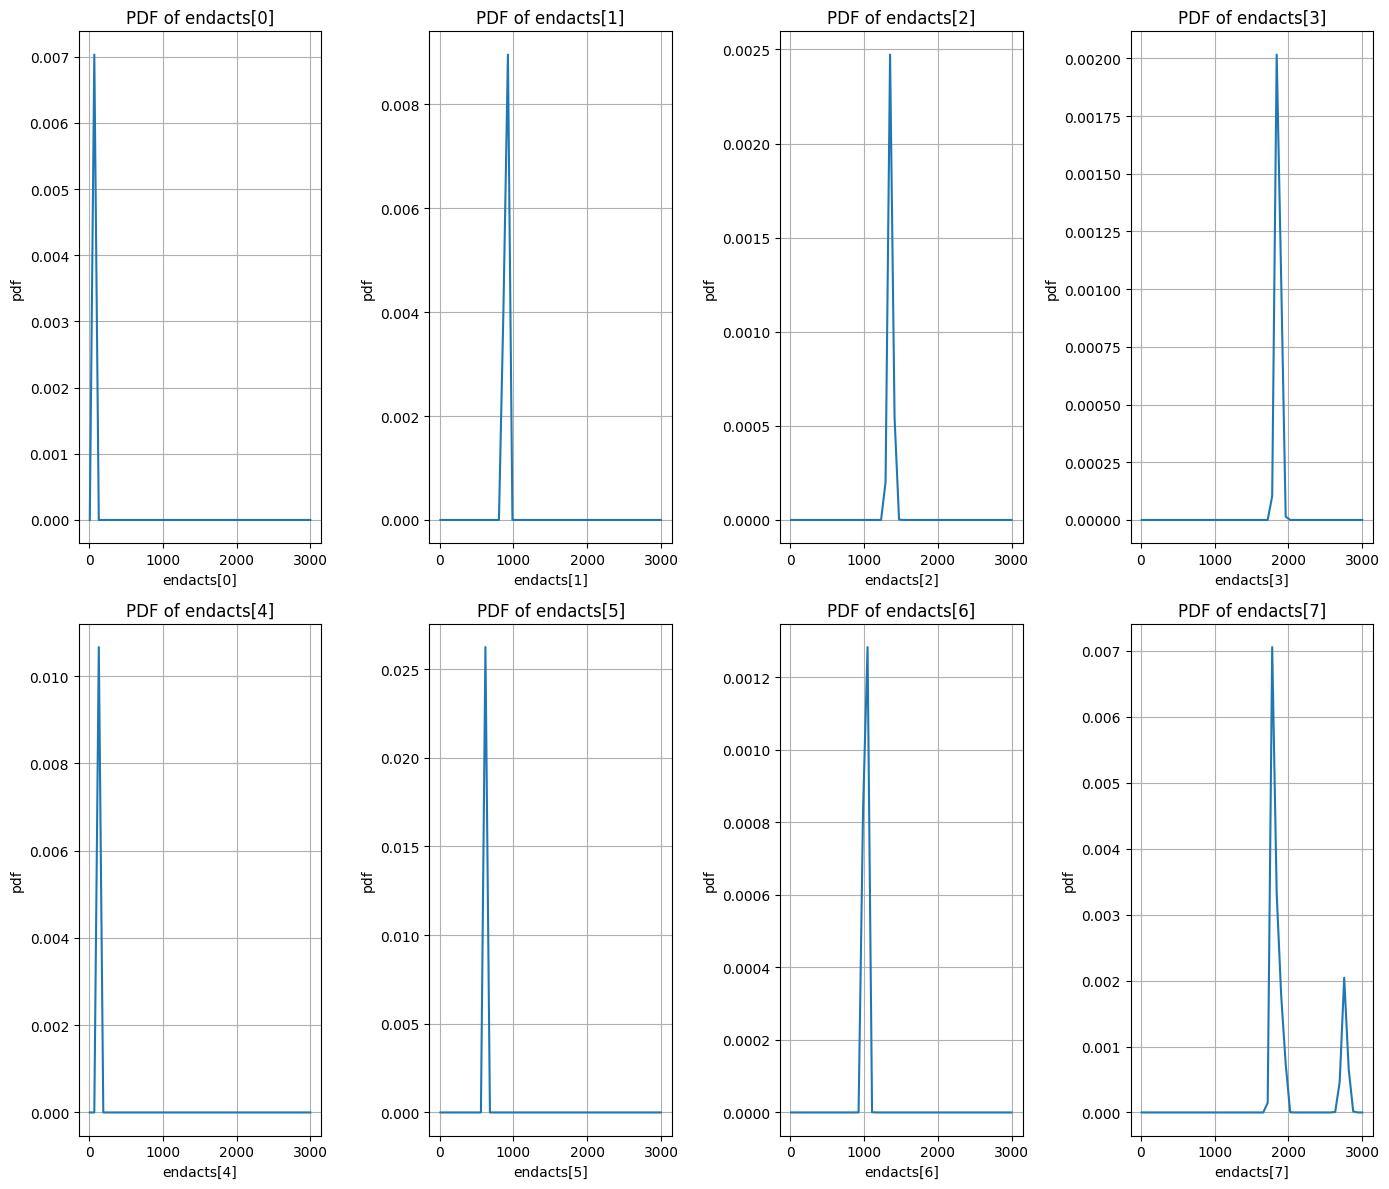

tensor([[1.9981e-23]], grad_fn=<MmBackward0>)


In [5]:
variables_to_plot = [
    "endacts[0]",
    "endacts[1]",
    "endacts[2]",
    "endacts[3]",
    "endacts[4]" ,
    "endacts[5]" ,
    "endacts[6]" ,
    "endacts[7]" ,
]

fig, axes = plt.subplots(2, 4, figsize=(14, 12))
axes = axes.flatten()

params_list = list(params_dict.values())
for i, var_name in enumerate(variables_to_plot):
    params_list = list(params_dict.values())
    #x_min = params_list[i]**2 * 0.5
    #x_max = params_list[i]**2 * 1.5
    x_min = 10
    x_max = 3000
    xs, pdf = hp.evaluate_marginal(output_dist, var_name, x_min, x_max, 50)

    ax = axes[i]
    ax.plot(xs.numpy(), pdf.numpy())
    ax.set_title(f"PDF of {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("pdf")
    ax.grid(True)

plt.tight_layout()
plt.show()
print(output_dist.gm.marg_pdf(torch.tensor([2200.]), output_dist.var_list.index('t')))

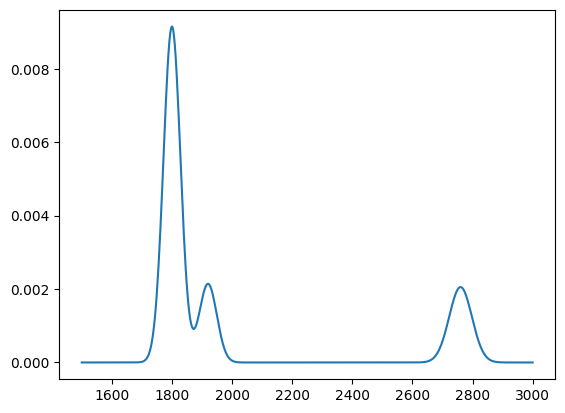

In [6]:
xs, pdf = hp.evaluate_marginal(output_dist, 't', 1500, 3000, 500)
plt.plot(xs.numpy(), pdf.numpy())

In [8]:
# generate synthetic data from the process

import torch

def shipment_process(params):
    """
    Simple torch implementation (single simulation).
    All internal structures are tensors.
    """

    device = torch.device("cpu")

    # ---- Parameters (squared as in original code) ----
    mu = torch.stack([
        torch.tensor(params["mu0"]**2, device=device),
        torch.tensor(params["mu1"]**2, device=device),
        torch.tensor(params["mu2"]**2, device=device),
        torch.tensor(params["mu3"]**2, device=device),
        torch.tensor(params["mu4"]**2, device=device),
        torch.tensor(params["mu5"]**2, device=device),
        torch.tensor(params["mu6"]**2, device=device),
        torch.tensor(params["mu7"]**2, device=device),
    ]).to(device)

    norm_prob = (params["norm"]**2)
    extra_prob = (params["extra"]**2)

    # ---- Activity durations: mu_i + Normal(0, std_i) ----
    stds = torch.tensor([5., 20., 30., 10., 5., 10., 20., 20.], device=device)
    tacts = mu + torch.randn(8, device=device) * stds

    # ---- Allocate tensors ----
    startacts = torch.zeros(8, device=device)
    endacts = torch.zeros(8, device=device)

    # ---- Parallel block ----
    startacts[0] = 0.
    startacts[1] = 0.

    # ---- Branch 0 ----
    endacts[0] = tacts[0]

    if torch.rand(()) < norm_prob:

        startacts[4] = endacts[0]
        endacts[4] = startacts[4] + tacts[4]

        if torch.rand(()) < extra_prob:
            startacts[6] = endacts[4]
            endacts[6] = startacts[6] + tacts[6]

        startacts[5] = endacts[4]
        endacts[5] = startacts[5] + tacts[5]

        branch0_end = torch.maximum(endacts[5], endacts[6])

    else:
        startacts[2] = endacts[0]
        endacts[2] = startacts[2] + tacts[2]

        startacts[3] = endacts[2]
        endacts[3] = startacts[3] + tacts[3]

        branch0_end = endacts[3]

    # ---- Branch 1 ----
    endacts[1] = tacts[1]
    branch1_end = endacts[1]

    # ---- Final join ----
    t = torch.maximum(branch0_end, branch1_end)

    startacts[7] = t
    endacts[7] = startacts[7] + tacts[7]
    t = endacts[7]

    return {
        "tacts": tacts,
        "startacts": startacts,
        "endacts": endacts,
        "t": t
    }

def simulate_n(n, params):
    endacts_all = torch.zeros((n, 8))
    startacts_all = torch.zeros((n, 8))
    tacts_all = torch.zeros((n, 8))
    t_all = torch.zeros(n)

    for i in range(n):
        out = shipment_process(params)
        endacts_all[i] = out["endacts"]
        startacts_all[i] = out["startacts"]
        tacts_all[i] = out["tacts"]
        t_all[i] = out["t"]
    return endacts_all, startacts_all, tacts_all, t_all


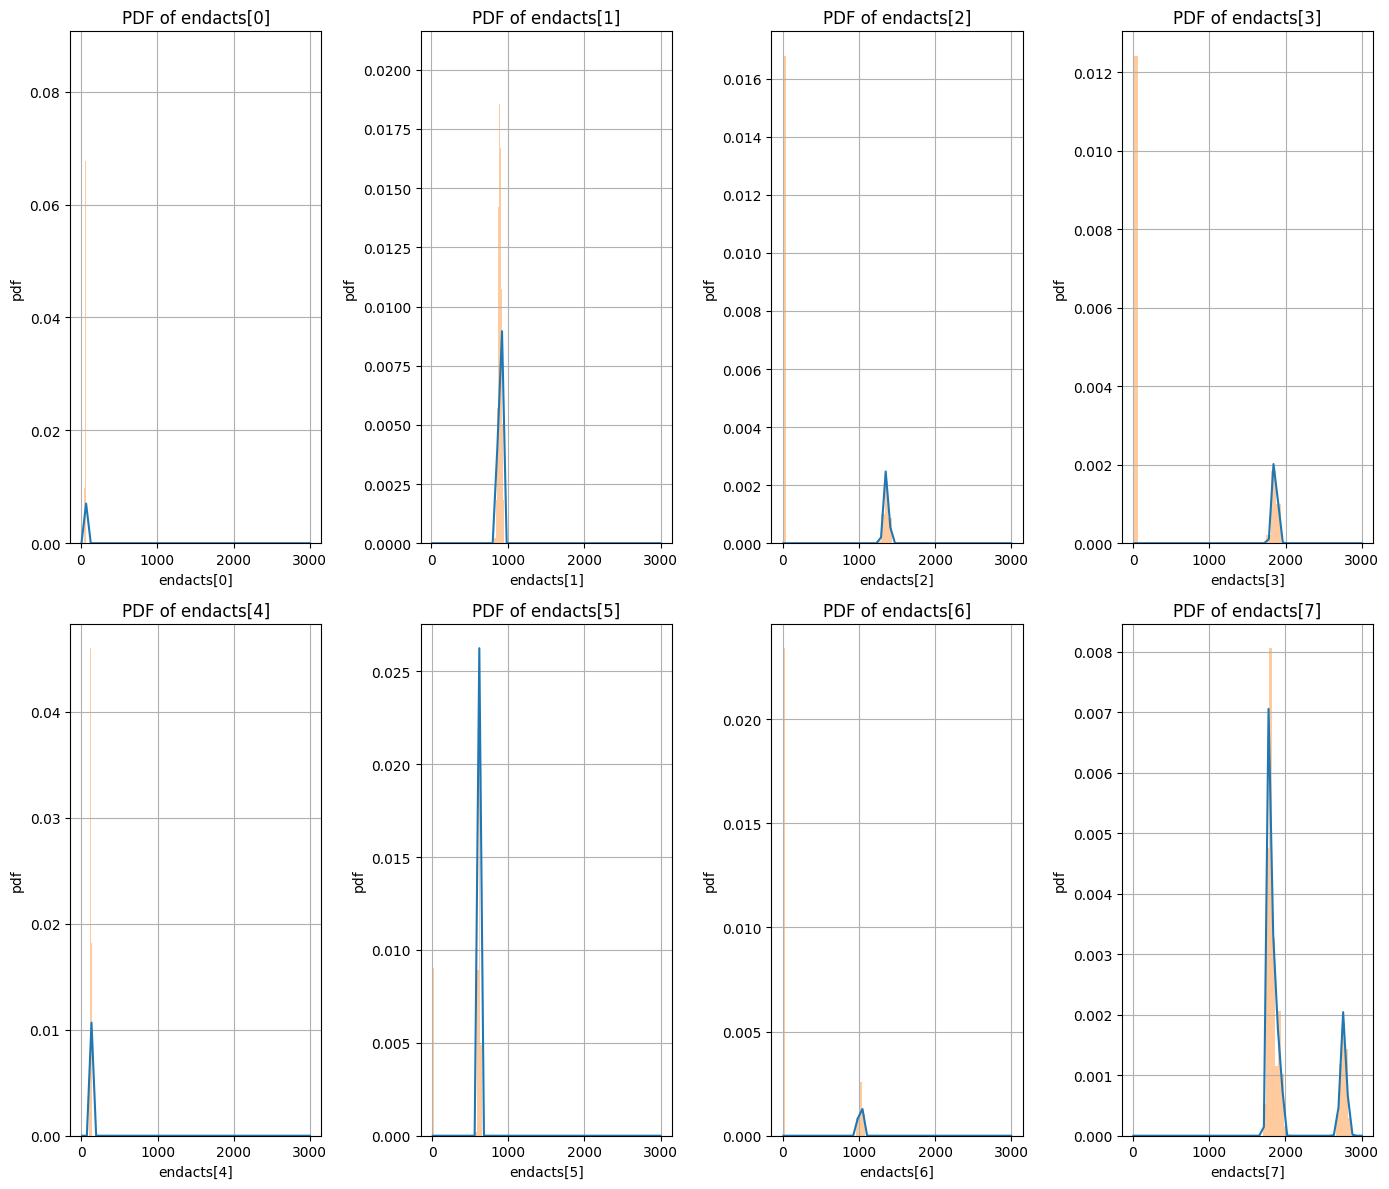

In [9]:
endacts_all, startacts_all, tacts_all, t_all = simulate_n(1000, params)

fig, axes = plt.subplots(2, 4, figsize=(14, 12))
axes = axes.flatten()
for i, var_name in enumerate(variables_to_plot):
    params_list = list(params_dict.values())
    #x_min = params_list[i]**2 * 0.5
    #x_max = params_list[i]**2 * 1.5
    x_min = 10
    x_max = 3000
    xs, pdf = hp.evaluate_marginal(output_dist, var_name, x_min, x_max, 50)

    ax = axes[i]
    ax.plot(xs.numpy(), pdf.numpy())
    ax.set_title(f"PDF of {var_name}")
    ax.set_xlabel(var_name)
    ax.set_ylabel("pdf")
    ax.grid(True)

    vals = [run[i] for run in endacts_all if run[i] is not None]
    ax.hist(vals, bins=30, density=True, alpha=0.4)
plt.tight_layout()
plt.show()

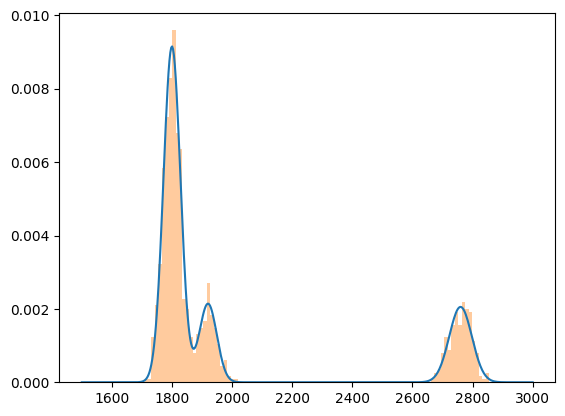

In [10]:
xs, pdf = hp.evaluate_marginal(output_dist, 't', 1500, 3000, 500)
plt.plot(xs.numpy(), pdf.numpy())
plt.hist(t_all.numpy(), bins=100, density=True, alpha=0.4)
plt.show()

In [11]:
def neg_log_likelihood_index(traj_set, dist, idx, idx_data):
    log_likelihood = torch.log(dist.gm.marg_pdf(traj_set[:, idx_data], idx))
    return - torch.sum(log_likelihood)

var_index = [output_dist.var_list.index('endacts['+ str(i) +']') for i in range(8)]
var_data_index = [i for i in range(8)]
print(var_index)
loss = lambda dist : neg_log_likelihood_index(endacts_all, dist, var_index, var_data_index)

print(loss(output_dist))

[16, 17, 18, 19, 20, 21, 22, 23]
tensor(6773.4615, grad_fn=<NegBackward0>)


LET'S NOW START FROM DIFFERENT PARAMETERS:

In [51]:
params = {'mu0':  60.,
          'mu1':  900., 
          'mu2':  1300.,
          'mu3':  500., 
          'mu4':  60., 
          'mu5':  500., 
          'mu6':  900.,
          'mu7':  900.,
          'norm': 0.1
          ,'extra': 0.5}

for key in params:
    params[key] = params[key]**0.5

Execution time: 0.34340929985046387 seconds


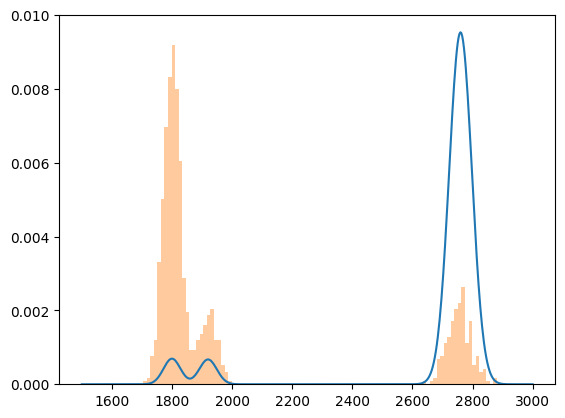

In [52]:
params_dict = initialize_params(params) 
compiledFile = compile2SOGA_text(soga_code)
cfg = produce_cfg_text(compiledFile)
smooth_cfg(cfg)
#measure execution time

start_time = time.time()

output_dist = start_SOGA(cfg, params_dict) 

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time} seconds")

xs, pdf = hp.evaluate_marginal(output_dist, 't', 1500, 3000, 500)
plt.plot(xs.numpy(), pdf.numpy())
plt.hist(t_all.numpy(), bins=100, density=True, alpha=0.4)
plt.show()

In [53]:
print(loss(output_dist))

tensor(8230.5411, grad_fn=<NegBackward0>)


In [54]:
params_dict = initialize_params(params) 

params_dict['mu0'].requires_grad = False
params_dict['mu1'].requires_grad = False
params_dict['mu2'].requires_grad = False
params_dict['mu3'].requires_grad = False
params_dict['mu4'].requires_grad = False
params_dict['mu5'].requires_grad = False
params_dict['mu6'].requires_grad = False
params_dict['mu7'].requires_grad = False

start_time = time.time()
# gradient based optimization
loss_list = optimize(cfg, params_dict, loss, n_steps=200, lr=0.01)

end_time = time.time()
execution_time = end_time - start_time
print(f"Optimization execution time: {execution_time} seconds")

compiledFile = compile2SOGA_text(soga_code)
cfg = produce_cfg_text(compiledFile)
smooth_cfg(cfg)

output_dist = start_SOGA(cfg, params_dict)

mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu5: 22.360679774997898 mu6: 30.0 mu7: 30.0 norm: 0.3262277660168123 extra: 0.6971067811866337  loss: 8230.541108045152
mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu5: 22.360679774997898 mu6: 30.0 mu7: 30.0 norm: 0.33623001762945953 extra: 0.6871221250385471  loss: 8180.027122440195
mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu5: 22.360679774997898 mu6: 30.0 mu7: 30.0 norm: 0.34623536201391397 extra: 0.6771600067383016  loss: 8129.702678763972
mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu5: 22.360679774997898 mu6: 30.0 mu7: 30.0 norm: 0.35624412578639264 extra: 0.6672259927079718  loss: 8079.568502365084
mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu

In [55]:
for key in params_dict:
    params_dict[key] = params_dict[key]**2

# print results:
for key, value in params_dict.items():
    print(f"{key}: {value.item()}")

mu0: 60.00000000000001
mu1: 900.0
mu2: 1300.0
mu3: 500.00000000000006
mu4: 60.00000000000001
mu5: 500.00000000000006
mu6: 900.0
mu7: 900.0
norm: 0.7859912029309608
extra: 0.19123100012935457


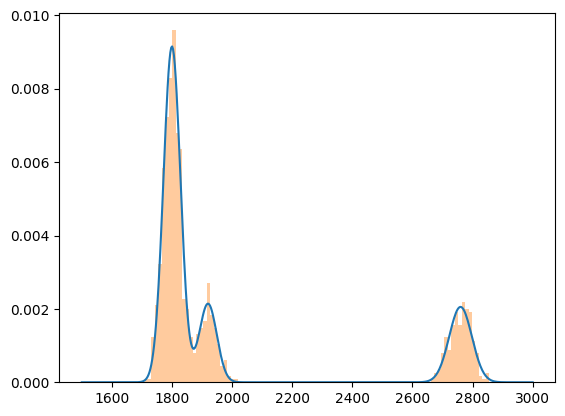

In [23]:
xs, pdf = hp.evaluate_marginal(output_dist, 't', 1500, 3000, 500)
plt.plot(xs.numpy(), pdf.numpy())
plt.hist(t_all.numpy(), bins=100, density=True, alpha=0.4)
plt.show()

In [57]:
print(loss(output_dist))

tensor(6720.5026, grad_fn=<NegBackward0>)


LOOK AT THE CORRELATION MATRIX

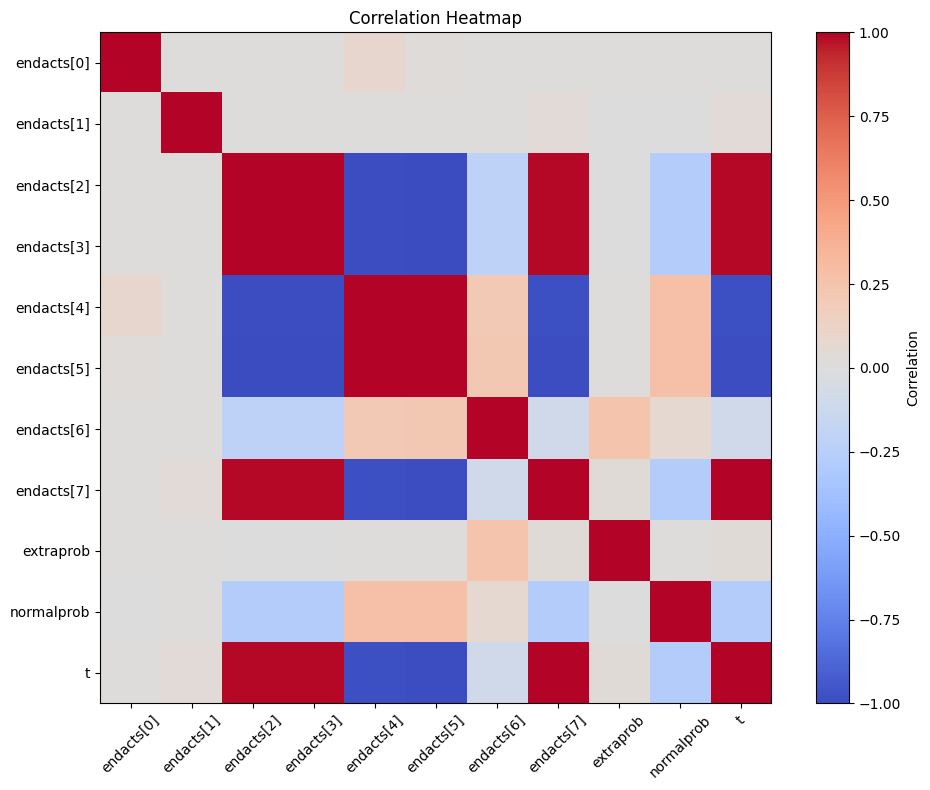

In [17]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_correlation_heatmap(output_dist, selected_vars):
    gm = output_dist.gm
    all_vars = output_dist.var_list

    # ---- normalize weights: fix shape (48,1) → (48,) ----
    w = gm.pi.squeeze()
    w = w / w.sum()
    K = w.shape[0]

    # ---- get indices for selected variables ----
    idx = [all_vars.index(v) for v in selected_vars]
    d   = len(idx)

    # ---- extract mixture means and covariances ----
    means = gm.mu[:, idx]                 # (48, d)
    covs  = gm.sigma[:, idx][:, :, idx]   # (48, d, d)

    # ---- global mean ----
    mu = torch.sum(w[:, None] * means, dim=0)    # (d,)

    # ---- between-component covariance ----
    diffs = means - mu[None, :]                  # (48, d)
    outer = diffs[:, :, None] * diffs[:, None, :]  # (48, d, d)

    # ---- global covariance ----
    Sigma = torch.sum(w[:, None, None] * (covs + outer), dim=0)  # (d, d)

    # ---- correlation matrix ----
    diag = torch.sqrt(torch.diag(Sigma))
    corr = Sigma / (diag[:, None] * diag[None, :])
    corr = corr.cpu().detach().numpy()

    # ---- plot ----
    plt.figure(figsize=(10, 8))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="Correlation")

    plt.xticks(range(d), selected_vars, rotation=45)
    plt.yticks(range(d), selected_vars)

    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
    return corr


selected = [
    "endacts[0]",
    "endacts[1]",
    "endacts[2]",
    "endacts[3]",
    "endacts[4]",
    "endacts[5]",
    "endacts[6]",
    "endacts[7]",   
    "extraprob",
    "normalprob",
    "t"
]

corr = plot_correlation_heatmap(output_dist, selected)


In [18]:
print(corr)

[[ 1.00000000e+00  1.00000296e-08  1.80534757e-03  1.32020600e-03
   8.40774823e-02  1.64013048e-02  2.11171090e-03  4.68781850e-03
   6.89978199e-14  1.38179720e-13  4.68781850e-03]
 [ 1.00000182e-08  1.00000000e+00  1.80534611e-11  1.32020088e-11
   8.40769629e-10  1.64022972e-10  2.11190661e-11  3.46745332e-02
  -9.62032800e-16 -1.76649752e-15  3.46745332e-02]
 [ 1.80534757e-03  1.80534611e-11  1.00000000e+00  9.99959659e-01
  -9.90878984e-01 -9.98687838e-01 -2.11540880e-01  9.90739090e-01
  -1.11428076e-14 -2.77738842e-01  9.90739090e-01]
 [ 1.32020600e-03  1.32020088e-11  9.99959659e-01  1.00000000e+00
  -9.91004283e-01 -9.98814124e-01 -2.11567630e-01  9.90695039e-01
  -1.11506921e-14 -2.77773962e-01  9.90695039e-01]
 [ 8.40774823e-02  8.40772007e-10 -9.90878984e-01 -9.91004283e-01
   1.00000000e+00  9.93616511e-01  2.10182308e-01 -9.80990801e-01
   4.01582489e-14  2.75376422e-01 -9.80990801e-01]
 [ 1.64013048e-02  1.64019258e-10 -9.98687838e-01 -9.98814124e-01
   9.93616511e-01  

In [36]:
factors, truncated_dist_2 = truncate(output_dist, 'endacts[5] > 10', {},{})
print(output_dist.gm.marg_cdf(torch.tensor([1800.]), output_dist.var_list.index('endacts[7]')))

tensor([[0.3245]], grad_fn=<MmBackward0>)


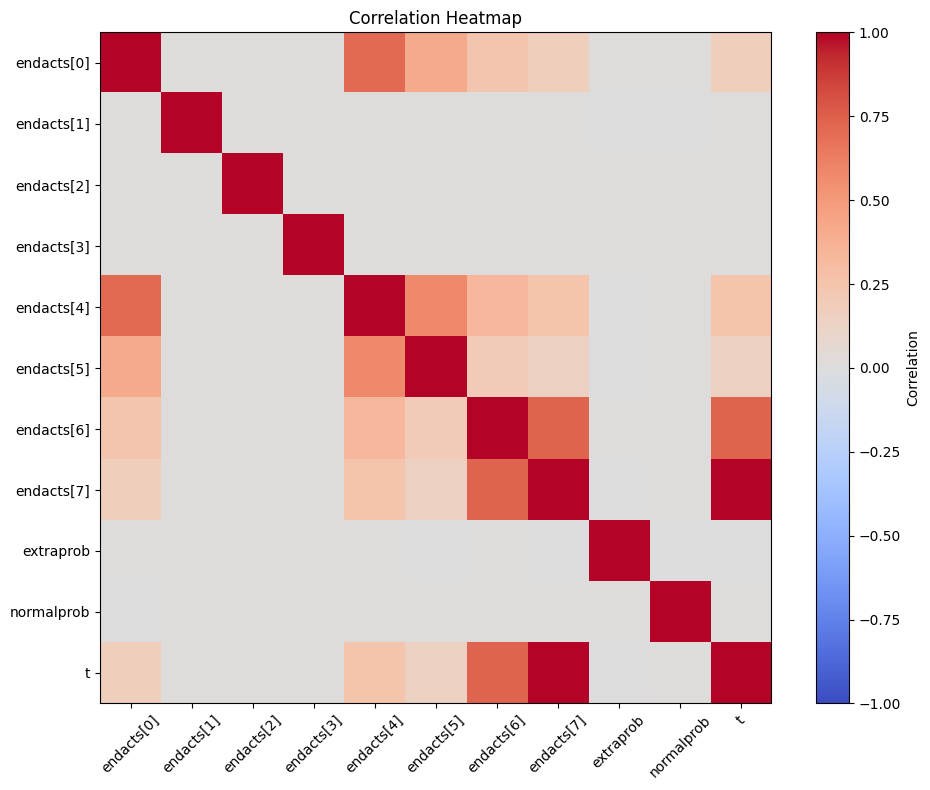

[[ 1.00000000e+00  1.00000870e-08  0.00000000e+00  0.00000000e+00
   7.07106781e-01  4.08248303e-01  2.35702272e-01  1.71496884e-01
   1.22640293e-17  1.79893364e-13  1.71496884e-01]
 [ 1.00000141e-08  1.00000000e+00  0.00000000e+00  0.00000000e+00
   7.07091869e-09  4.08285852e-09  2.35716930e-09  1.32264755e-05
  -8.21900710e-15 -2.20791277e-14  1.32264755e-05]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 7.07106781e-01  7.07102158e-09  0.00000000e+00  0.00000000e+00
   1.00000000e+00  5.77350287e-01  3.33333350e-01  2.42533220e-01
  -9.89107071e-16  1.09051469e-13  2.42533219e-01]
 [ 4.08248303e-01  4.08238286e-09  0.00000000e+00  0.00000000e+00
   5.77350287e-01  

In [19]:
factors, truncated_dist = truncate(output_dist, 'endacts[6] > 10', {},{})
trunc_corr = plot_correlation_heatmap(truncated_dist, selected)
print(trunc_corr)

OPTIMIZE WITH A TARGET

In [18]:
loss = lambda output_dist: -output_dist.gm.marg_pdf(torch.tensor([2000.]), output_dist.var_list.index('t'))
print(loss(output_dist))

tensor([[-5.3897e-05]], grad_fn=<NegBackward0>)


mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu5: 22.360679774997898 mu6: 30.0 mu7: 30.0 norm: 0.8954271167527115 extra: 0.4482135623981789  loss: -4.725566569056355e-05
mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu5: 22.360679774997898 mu6: 30.0 mu7: 30.0 norm: 0.8964271221565688 extra: 0.44921371112253244  loss: -4.7693714947424795e-05
mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu5: 22.360679774997898 mu6: 30.0 mu7: 30.0 norm: 0.8974272541630839 extra: 0.45021416054982544  loss: -4.813442628233727e-05
mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 7.745966692414834 mu5: 22.360679774997898 mu6: 30.0 mu7: 30.0 norm: 0.898427554957693 extra: 0.4512150275156609  loss: -4.8577820408420574e-05
mu0: 7.745966692414834 mu1: 30.0 mu2: 36.05551275463989 mu3: 22.360679774997898 mu4: 

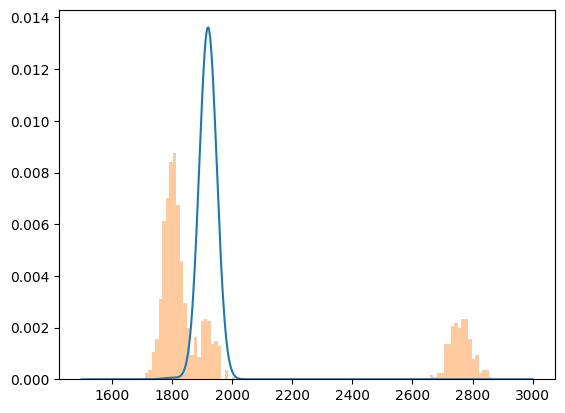

In [ ]:
params = {'mu0':  60.,
          'mu1':  900., 
          'mu2':  1300.,
          'mu3':  500., 
          'mu4':  60., 
          'mu5':  500., 
          'mu6':  900.,
          'mu7':  900.,
          'norm': 0.8
          ,'extra': 0.2}

#square root all parameters to ensure positivity
for key in params:
    params[key] = params[key]**0.5
    

params_dict = initialize_params(params) 

params_dict['mu0'].requires_grad = False
params_dict['mu1'].requires_grad = False
params_dict['mu2'].requires_grad = False
params_dict['mu3'].requires_grad = False
params_dict['mu4'].requires_grad = False
params_dict['mu5'].requires_grad = False
params_dict['mu6'].requires_grad = False
params_dict['mu7'].requires_grad = False


start_time = time.time()
# gradient based optimization
loss_list = optimize(cfg, params_dict, loss, n_steps=2000, lr=0.001)

end_time = time.time()
execution_time = end_time - start_time
print(f"Optimization execution time: {execution_time} seconds")

compiledFile = compile2SOGA_text(soga_code)
cfg = produce_cfg_text(compiledFile)
smooth_cfg(cfg)

output_dist = start_SOGA(cfg, params_dict)

xs, pdf = hp.evaluate_marginal(output_dist, 't', 1500, 3000, 500)
plt.plot(xs.numpy(), pdf.numpy())
plt.hist(t_all.numpy(), bins=100, density=True, alpha=0.4)
plt.show()

LOOK AT THE GRADIENTS TO CHECK IMPORTANCE OF ACTIVITIES WRT TOTAL TIME

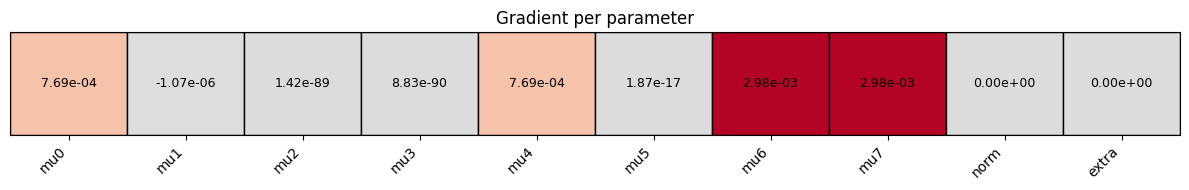

{'mu0': 0.00076942216401149, 'mu1': -1.065825967770669e-06, 'mu2': 1.4244519214820226e-89, 'mu3': 8.834075800806157e-90, 'mu4': 0.00076942216401149, 'mu5': 1.8716649046829394e-17, 'mu6': 0.0029799592274193723, 'mu7': 0.002978893401451733, 'norm': 0.0, 'extra': 0.0}


In [37]:
loss = lambda output_dist: -output_dist.gm.marg_cdf(torch.tensor([2000.]), output_dist.var_list.index('t'))
params = {'mu0':  60.,
          'mu1':  900., 
          'mu2':  1300.,
          'mu3':  500., 
          'mu4':  60., 
          'mu5':  500., 
          'mu6':  900.,
          'mu7':  900.,
          'norm': 0.8
          ,'extra': 0.2}

#square root all parameters to ensure positivity
for key in params:
    params[key] = params[key]**0.5
    

params_dict = initialize_params(params) 

import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_gradient_squares(cfg, params_dict, loss_func):
    """
    Compute the gradient of the loss w.r.t. each parameter once,
    then display one colored square per parameter.

    Positive and negative gradients are shown with opposite signs
    in the colormap, and intensity reflects magnitude.
    """

    # clear old gradients
    for param in params_dict.values():
        if param.grad is not None:
            param.grad.zero_()
    
    params_dict['norm'].requires_grad = False
    params_dict['extra'].requires_grad = False

    # forward pass
    current_dist = start_SOGA(cfg, params_dict)
    loss = loss_func(current_dist)

    # backward pass
    loss.backward()

    # collect gradients
    names = []
    grads = []

    for key, param in params_dict.items():
        names.append(key)
        if param.grad is None:
            grads.append(0.0)
        else:
            grads.append(param.grad.detach().item())

    grads_tensor = torch.tensor(grads, dtype=torch.float32)

    # normalize symmetrically around zero for coloring
    max_abs = torch.max(torch.abs(grads_tensor)).item()
    if max_abs == 0:
        max_abs = 1.0

    norm_grads = grads_tensor / max_abs  # values in [-1, 1]

    # plot
    fig, ax = plt.subplots(figsize=(1.2 * len(names), 2))

    cmap = plt.cm.coolwarm

    for i, (name, g, ng) in enumerate(zip(names, grads, norm_grads)):
        color = cmap((ng.item() + 1) / 2)  # map [-1,1] -> [0,1]
        rect = Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='black')
        ax.add_patch(rect)

        # gradient value written inside the square
        ax.text(
            i + 0.5, 0.5,
            f"{g:.2e}",
            ha='center', va='center',
            fontsize=9
        )

    ax.set_xlim(0, len(names))
    ax.set_ylim(0, 1)
    ax.set_xticks([i + 0.5 for i in range(len(names))])
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_yticks([])
    ax.set_title("Gradient per parameter")
    plt.tight_layout()
    plt.show()

    return {name: grad for name, grad in zip(names, grads)}

grad_dict = plot_gradient_squares(cfg, params_dict, loss)
print(grad_dict)